# 3.0 Model training - Ridge


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    create_model_gridsearch
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable,get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2025-12-22 20:50:56.032 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
ALPHA = 1000
CV_SPLITS = 5
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
dates = features[VISIT_DATE_COL].copy()
X = features
y = labels

In [6]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False, random_state=42
)
X_train = X_train_full.drop(columns=DROP_COLUMNS)
X_test = X_test_full.drop(columns=DROP_COLUMNS)

split_idx = len(X_train)
train_dates = dates.iloc[:split_idx].reset_index(drop=True)
test_dates = dates.iloc[split_idx:].reset_index(drop=True)

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-02-16 00:00:00
Test set dates: 2017-02-16 00:00:00 to 2017-04-22 00:00:00


## Train


I haven't added the feature update (lags and rolling) yet.

In [7]:
grid_search = create_model_gridsearch(verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 63 candidates, totalling 189 fits
Best parameters: {'ridge__alpha': np.float64(1000.0), 'selector__estimator__alpha': 0.1, 'selector__threshold': 'mean'}
Best score: -10.83127614743995


In [8]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge__alpha,param_selector__estimator__alpha,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
61,16.364999,0.800369,0.075755,0.027273,1000.0,0.1,mean,"{'ridge__alpha': 1000.0, 'selector__estimator_...",-13.963067,-9.011345,-9.519417,-10.831276,2.224203,1
52,16.846231,1.351255,0.072525,0.001975,100.0,0.1,mean,"{'ridge__alpha': 100.0, 'selector__estimator__...",-13.981606,-9.018319,-9.522931,-10.840952,2.230312,2
43,14.774964,1.070199,0.091737,0.020852,10.0,0.1,mean,"{'ridge__alpha': 10.0, 'selector__estimator__a...",-13.983484,-9.019095,-9.523305,-10.841962,2.230909,3
34,16.911826,1.120095,0.077366,0.009461,1.0,0.1,mean,"{'ridge__alpha': 1.0, 'selector__estimator__al...",-13.983672,-9.019174,-9.523343,-10.842063,2.230968,4
25,17.510140,0.116279,0.084492,0.028847,0.1,0.1,mean,"{'ridge__alpha': 0.1, 'selector__estimator__al...",-13.983691,-9.019182,-9.523347,-10.842073,2.230974,5


In [12]:
model = grid_search.best_estimator_
sel = model.named_steps.get("selector", None)
support = sel.get_support()
selected_cols = X_train.columns[support]

print("Selected features:", list(selected_cols))

Selected features: ['open_usually', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_dow_mean', 'res_visitors_diff', 'res_visitors_diff_mean_14']


In [13]:
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.9242
MAE:  7.2468
R2:   0.5598


In [14]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test_full,
    X_train_full,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/66 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[23.6232316   4.25946988 16.34294618  5.48089309 15.43369902 20.72416338
 17.11037827 22.86552624 35.76322329 12.96763518  5.34884809 17.52649395
 15.68480011 14.13466275 26.49305437  5.74261649 26.67286252 23.29580159
 16.23814237 12.56447905 15.5620931  30.80467499 10.89218486 52.92077016
 11.50592831 11.7393743   5.9145117   7.87064412  0.         11.03347702
 25.32669556 14.44420122 28.26130102  9.20183746 32.65410358 15.86157162
 42.7102223  13.34617787 18.44696054 28.40973082 15.1027061

In [15]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8755
MAE:  7.5154
R2:   0.5406


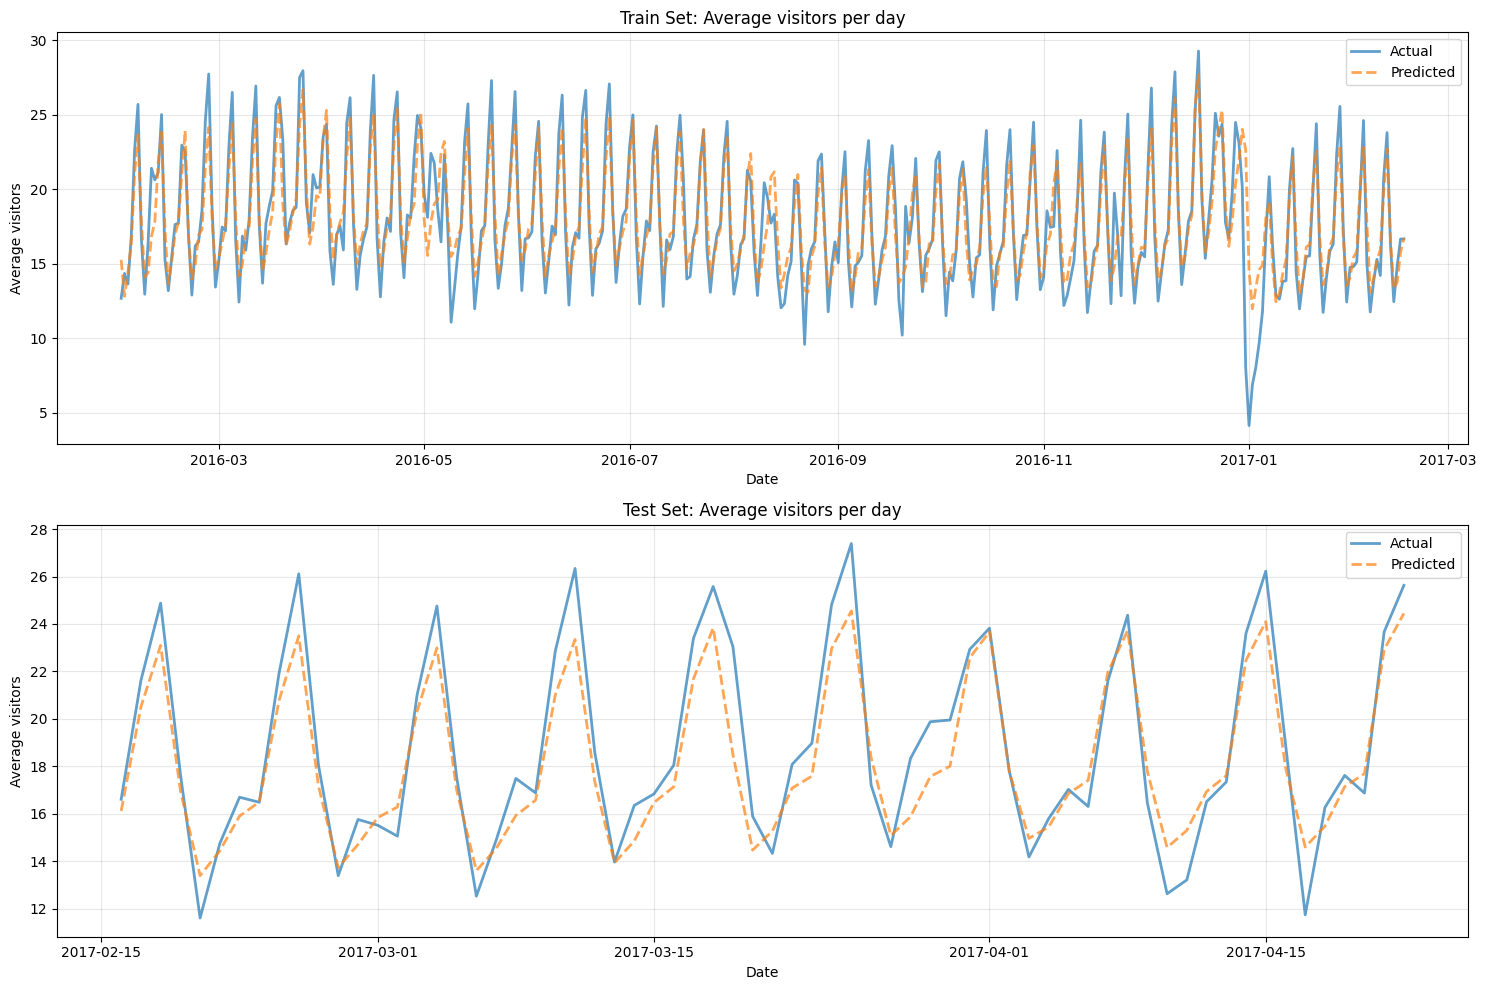

In [17]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [18]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [19]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.18642449e+00 0.00000000e+00 1.04921221e+01 6.29277827e+00
 2.39866476e+01 2.60008095e+01 2.68210140e+01 7.26226667e+00
 3.77612998e+01 2.29272401e+00 2.50327210e+01 5.11087575e+00
 2.97733842e+01 4.67489879e+01 2.47574984e+01 5.99309922e+00
 1.53579164e+01 1.21390260e+01 2.47319996e+01 4.80240510e+01
 7.32583465e+00 1.62913510e+01 1.51298506e+01 1.79621829e+01
 3.17202433e-01 2.81865974e+01 1.34270759e+01 1.98535950e+01
 3.28643935e-02 1.50979724e+01 2.11921016e+01 8.75433145e+00
 2.046548

In [20]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [21]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
    "selected_features": list(selected_cols) if 'selected_cols' in globals() else None,
    "n_features": len(selected_cols) if 'selected_cols' in globals() else None,
}

params_path = MODELS_DIR / "ridge_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)